In [1]:
import pandas as pd

df = pd.read_csv('../../data/my_dataset.csv')
df.head()

,OyuncuID,Dogum_Tarihi,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
0,1000,1999-03-29,27,2025-05-02,2026-02-13,13,55,50,38,158,25,1,1.2
1,1001,2003-04-29,23,2025-10-27,2026-05-25,45,0,18,42,106,20,1,0.7
2,1002,2007-11-26,18,2024-05-17,2025-06-11,54,183,44,48,331,36,1,2.1
3,1003,1997-07-01,29,2024-08-26,2026-05-29,95,58,94,92,341,36,1,1.9
4,1004,2003-08-27,22,2023-08-13,2024-07-11,45,104,46,45,241,31,1,2.9


In [2]:
df.isnull().sum()

OyuncuID          0
Dogum_Tarihi      0
Yas               0
Kayit_Tarihi      0
Son_Giris         0
Ilkbahar_Saati    0
Yaz_Saati         0
Sonbahar_Saati    0
Kis_Saati         0
Toplam_Saat       0
OyuncuSeviyesi    0
Churn_Durumu      0
Hesap_Yasi        0
dtype: int64

In [3]:
df.describe()

,OyuncuID,Yas,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5999.50000,24.431200,70.569400,117.421300,62.751400,67.135200,319.115700,32.211700,0.460900,1.963950
std,2886.89568,5.025932,48.191134,115.495292,45.637722,46.594708,230.547267,14.447178,0.498494,0.914433
min,1000.00000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.100000
25%,3499.75000,21.000000,38.000000,32.000000,27.000000,36.000000,115.000000,21.000000,0.000000,1.200000
50%,5999.50000,24.000000,63.000000,86.000000,48.000000,56.000000,292.000000,34.000000,0.000000,2.200000
75%,8499.25000,28.000000,116.000000,152.000000,93.000000,97.000000,495.000000,44.000000,1.000000,2.800000
max,10999.00000,43.000000,149.000000,486.000000,147.000000,148.000000,901.000000,60.000000,1.000000,3.000000


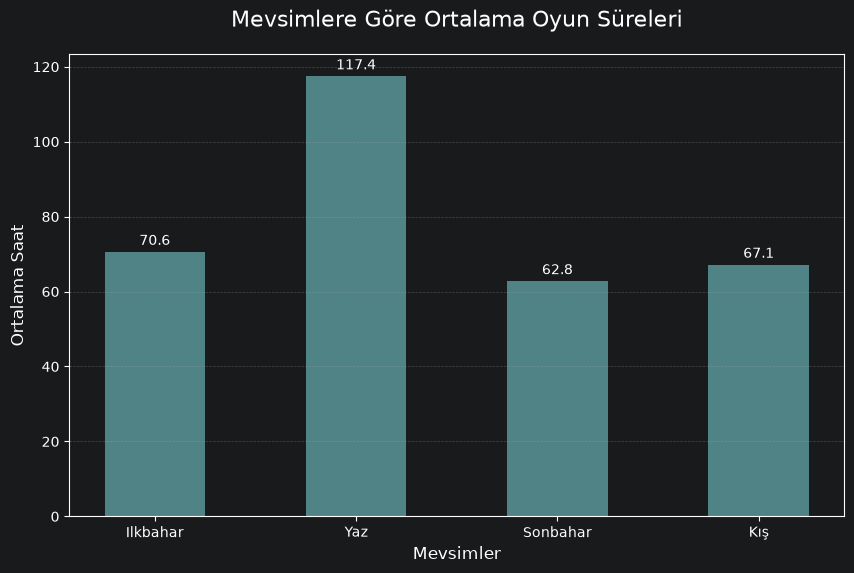

In [4]:
import matplotlib.pyplot as plt


mevsimler = ['Ilkbahar', 'Yaz', 'Sonbahar', 'Kış']


mevsimlik_ortalamalar = [
    df['Ilkbahar_Saati'].mean(),
    df['Yaz_Saati'].mean(),
    df['Sonbahar_Saati'].mean(),
    df['Kis_Saati'].mean()
]

plt.figure(figsize=(10, 6))


bars = plt.bar(mevsimler, mevsimlik_ortalamalar, color='#5F9EA0', alpha=0.8, width=0.5)


plt.title('Mevsimlere Göre Ortalama Oyun Süreleri', fontsize=16, pad=20)
plt.ylabel('Ortalama Saat', fontsize=12)
plt.xlabel('Mevsimler', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 1), ha='center', va='bottom', fontsize=10)

plt.show()

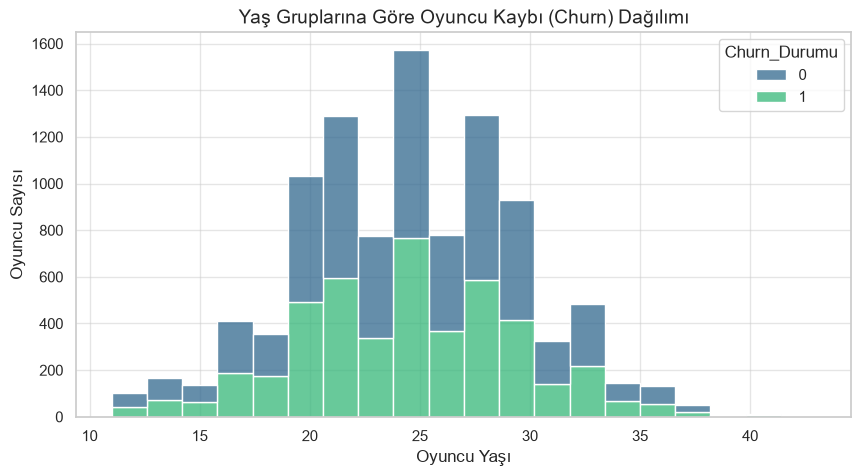

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/my_dataset.csv")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='Yas', hue='Churn_Durumu',
             multiple='stack',
             palette='viridis',
             bins=20)

plt.title('Yaş Gruplarına Göre Oyuncu Kaybı (Churn) Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Yaşı')
plt.ylabel('Oyuncu Sayısı')
plt.show()

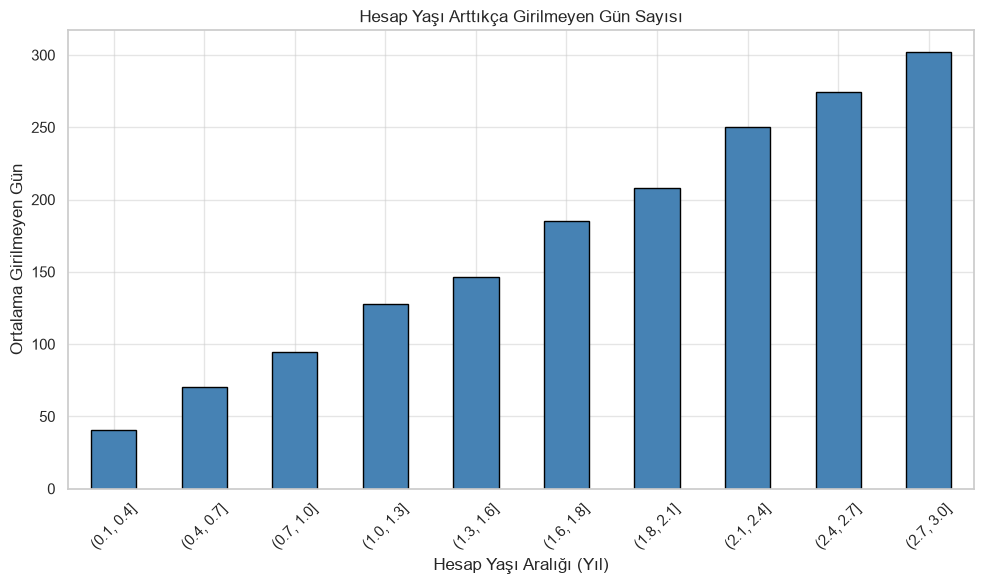

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/my_dataset.csv")

df["Son_Giris"] = pd.to_datetime(df["Son_Giris"])
bugun = pd.Timestamp.now()
df["Girilmeyen_Gun"] = (bugun - df["Son_Giris"]).dt.days

df["Hesap_Yasi_Grup"] = pd.cut(df["Hesap_Yasi"], bins=10, precision=0)
grup_ortalama = df.groupby("Hesap_Yasi_Grup", observed=True)["Girilmeyen_Gun"].mean()


plt.figure(figsize=(10, 6))
grup_ortalama.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Hesap Yaşı Arttıkça Girilmeyen Gün Sayısı")
plt.xlabel("Hesap Yaşı Aralığı (Yıl)")
plt.ylabel("Ortalama Girilmeyen Gün")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
